# Simple Linear Regression by me

In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
%matplotlib inline

In [2]:
## Read the dataset

df = pd.read_csv('height-weight.csv')
df.head()


,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


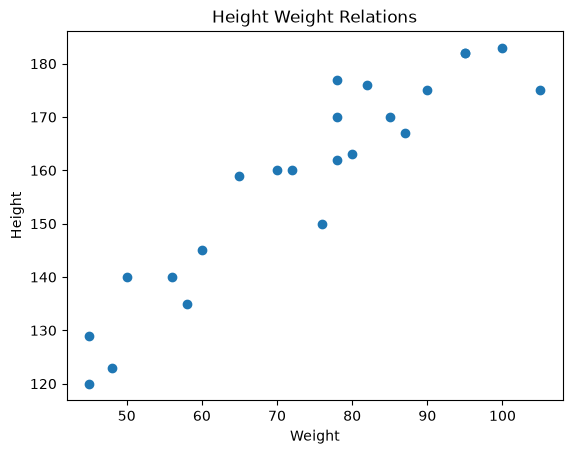

In [3]:
plt.scatter(df['Weight'], df['Height'])
plt.xlabel("Weight")
plt.ylabel("Height")
plt.title("Height Weight Relations")

plt.show()
# our main aim to create best fit line

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [5]:
# devide our dataset into independent and dependent features

X = df[['Weight']]        # independent features
y = df['Height']        # dependent features

In [6]:
# Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)


In [7]:
X.shape

(23, 1)

In [8]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [9]:
# Standardize the dataset Train independent data

from sklearn.preprocessing import StandardScaler

In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [11]:
X_test = scaler.transform(X_test)
X_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

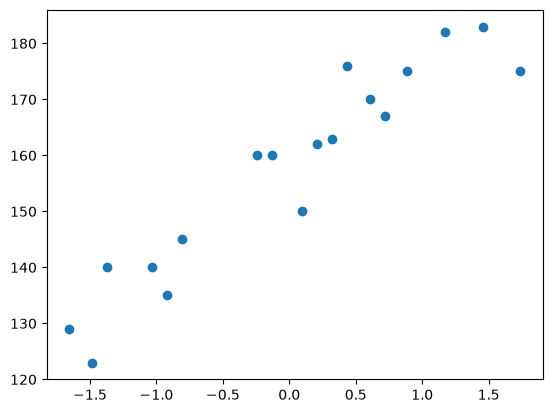

In [12]:
plt.scatter(
    X_train, y_train
)

In [13]:
# Train the simple Linear Regression Model

from sklearn.linear_model import LinearRegression

regressor = LinearRegression()

In [14]:
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.03]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,157.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.24]


In [15]:
print(f'The slope or coefficient of weight is: {regressor.coef_}')
print(f'Intercept: {regressor.intercept_}')

The slope or coefficient of weight is: [17.03440872]
Intercept: 157.5


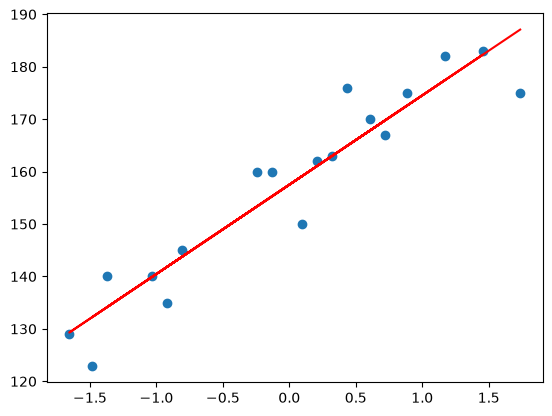

In [16]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regressor.predict(X_train),'r')

### Prediction of train data
```python
1. Predicted height output = intercept + coef_(Weights)
2. y_pred_train = 157.5 + 17.03(X_train)
```

### Prediction of test data
```python
1. prediction height output = intercent + coef_(Weights) 
2. y_pred_test = 157.5 + 17.03(X_test)
```

In [17]:
y_pred_test = regressor.predict(X_test)
y_pred_test, np.array(y_test)

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 array([177, 170, 120, 182, 159]))

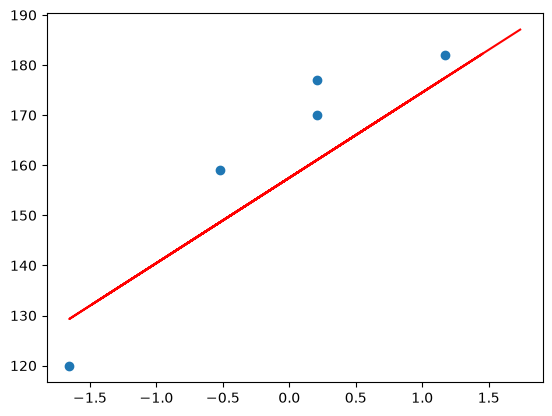

In [18]:
plt.scatter(X_test, y_test)
plt.plot(X_train, regressor.predict(X_train), 'r')

## Performance Metrics

## MSE, MAE, RMSE
## R square and adjusted R squuare


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [20]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
print(f'MSE: {mse}')
print(f'MAE: {mae}')
print(f'RMSE: {np.sqrt(mse)}')

MSE: 109.77592599051664
MAE: 9.822657814519232
RMSE: 10.477400726827081


## R square
Formula

R^2 = 1 - SSR/SST

R^2 = coeffcient od determination SSR = sum of square of residuals SST = total sum of squares

In [21]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred_test)
score

0.776986986042344

In [22]:
## new data points weight is 80

scaled_weight = scaler.transform([[80]])
scaled_weight

g:\My Drive\AL-ML by Krish Naik\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [26]:
print(f"Hight prediction for weight 80 kg is : {regressor.predict(scaled_weight)}")

Hight prediction for weight 80 kg is : [163.01076266]


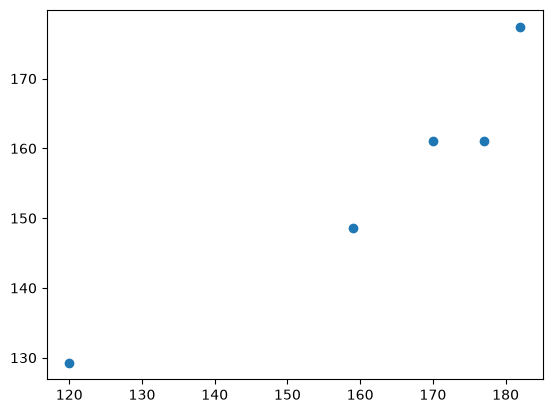

In [27]:
## Assumption
## plot a scatter plot for the prediction

plt.scatter(y_test, y_pred_test)

C:\Users\vikas\AppData\Local\Temp\ipykernel_16480\3980089401.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde=True)


<Axes: xlabel='Height', ylabel='Density'>

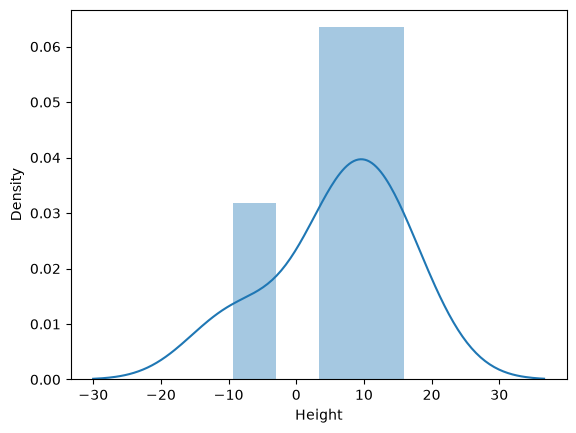

In [33]:
## Rediduals

residuals = y_test-y_pred_test
residuals

# plot this residuals
import seaborn as sns

sns.distplot(residuals, kde=True)